In [8]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST', 'localhost')}:{os.getenv('DB_PORT', '5432')}"
    f"/{os.getenv('DB_NAME')}"
)

df = pd.read_sql("SELECT COUNT(*) AS n FROM hiring_signals", engine)
df

,n
0,62951


## Today's hiring footprint by ticker

Each ticker's "open jobs" count is the number of distinct job postings visible on their public careers site at scrape time.
This is a point-in-time inventory ("how big is each company's hiring book right now"), not a flow ("how fast are they hiring") — that comes later.

In [9]:
today_jobs = pd.read_sql("""
    SELECT 
        ticker,
        COUNT(*)            AS n_jobs,
        COUNT(posted_date)  AS with_date,
        COUNT(category)     AS with_category,
        MIN(posted_date)    AS oldest_posted,
        MAX(posted_date)    AS newest_posted
    FROM hiring_signals
    WHERE snapshot_date = CURRENT_DATE
    GROUP BY ticker
    ORDER BY n_jobs DESC
""", engine)

today_jobs

,ticker,n_jobs,with_date,with_category,oldest_posted,newest_posted
0,MU,3024,3023,2858,2024-05-23,2026-05-31
1,NVDA,2654,2654,2654,2026-05-02,2026-06-01
2,QCOM,1985,1985,1985,2025-03-12,2026-05-31
3,AMD,1087,1087,1087,2025-05-07,2026-06-01
4,INTC,715,714,0,2026-05-02,2026-06-01
5,MRVL,677,677,0,2026-05-02,2026-06-01
6,CDNS,623,623,0,2026-05-02,2026-06-01
7,TXN,470,470,0,2025-02-05,2026-06-01
8,AVGO,338,338,0,2026-05-02,2026-06-01


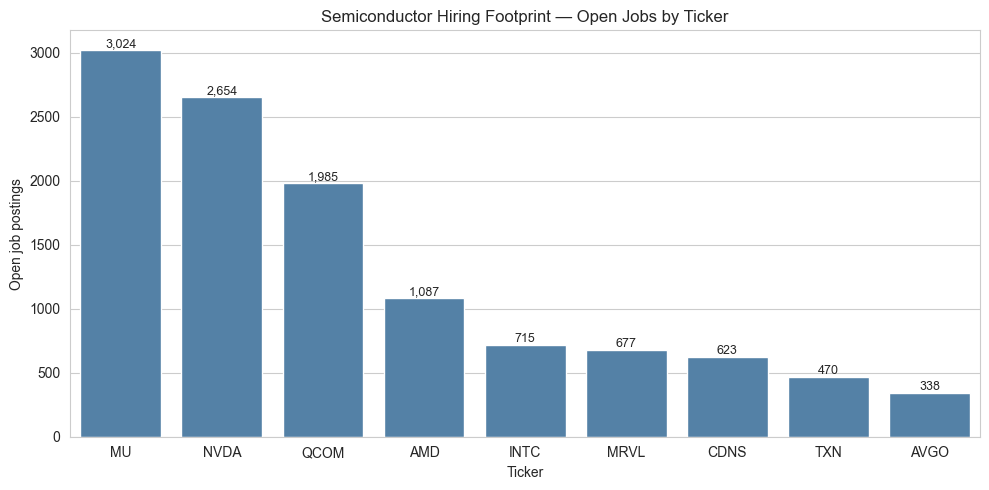

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=today_jobs,
    x="ticker", y="n_jobs",
    order=today_jobs["ticker"].tolist(),
    ax=ax, color="steelblue",
)
ax.set_title("Semiconductor Hiring Footprint — Open Jobs by Ticker")
ax.set_xlabel("Ticker")
ax.set_ylabel("Open job postings")
for i, n in enumerate(today_jobs["n_jobs"]):
    ax.text(i, n, f"{n:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

### Observations (Initial observations made via Claude Guiding Questions & Discussion)

- **MU leads the hiring book at 3,024 open postings, ahead of NVDA's 2,654.** 
 This is surprising on first read given NVDA's profile, but likely reflects Micron's active fab expansion as they're staffing megaprojects, not just maintaining headcount. Also, differences in numbers could be attributed to companies having differing global presences/counts of involvement within different industries.

- **Raw counts overstate large/diversified companies.** 
 NVDA ~2,654 / ~42k ≈ 6.3% open-role ratio vs MU ~3,024 / ~53k ≈ 5.7%. 
 This tells us that this larger job opening count isn't as representative of the slight anomaly as expected as NVDA still has a higher hiring intensity despite the lower count which is attributed to MU having an overall higher employee count.

- **AVGO is the anomaly worth watching.**
 Broadcom despite being much larger than Cadence (~$1T market cap, ~37k employees) vs (~$90B, ~13k employees), has a very low open job listing count worth looking into.

- **Open question to test next:** 
 is the cross-ticker count driven by *global geographic spread* (`location` field) or *sector breadth* (`category` field, where available)?